In [29]:
%load_ext autoreload
%autoreload 2

%reload_ext autoreload

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [2]:
from satellite_RFI.src.satellite_sims import satellite_sim as ss
import time
import pickle
import astropy.units as u
from datetime import datetime
import tqdm
import os


import scipy as sp
import numpy as np
import pandas as pd
import scipy.optimize as opt
import matplotlib.pyplot as plt

In [3]:
obs_time_input=None#'2021 9 30 20 06 36'
# fname = '1554156377'
fname = '1551055211'


"""
Establishing the file name
"""
if obs_time_input!=None:
    obs_time_in=[int(x) for x in obs_time_input.split()]
    obs_time = datetime(obs_time_in[0], obs_time_in[1], obs_time_in[2], obs_time_in[3], obs_time_in[4], obs_time_in[5])
    dt = obs_time.strftime('%Y-%m-%d %H:%M:%S')
    fname = int((obs_time - datetime(1970, 1, 1)).total_seconds())
    print ("File name to be used is: "+str(fname))

else:
    print ("File name to be used is: "+str(fname))
    dt = (datetime.utcfromtimestamp(float(fname)).strftime('%Y-%m-%d %H:%M:%S'))
    print ("Date of observation date: "+str(dt))



File name to be used is: 1551055211
Date of observation date: 2019-02-25 00:40:11


In [4]:
katdal_info = pickle.load(open('../../Observation_results/Untangle/'+str(fname)+'/'+str(fname)+'_katdal_info.p', 'rb'), encoding='latin1')



info = [katdal_info[i] for i in katdal_info.keys()]

nd_s0=katdal_info['nd_s0']
nd_s0_coords=katdal_info['nd_s0_coords']
frequency=katdal_info['frequency']
fs=1000
fe=1500

data_save='../../Observation_results/Untangle/'+str(fname)+'/sat_sims/'
if os.path.exists(data_save)==False:
    os.mkdir(data_save)
else:
    print('Path exists')
    
data_mkat = '../../Observation_results/Untangle/'+str(fname)+'/'

Path exists


Running a validation check using, one constellation and applying a gaussian shift to the data

$\bullet$ GPS constellation switched on and alpha is constant at 1

In [5]:
sims = ss(file_name=fname, sats_only=None, data_loc=data_mkat, sat_loc='../../Observation_results/Untangle/'+str(fname)+'/',
            survey_info=[nd_s0, nd_s0_coords, frequency], sat_info='Satellite_simulations/Satellite_Catalogue/table3B_satellite_v3-1.csv',
            plots_loc='../../Observation_results/Untangle/Plots/'+str(fname)+'/',
            sat_beam='emss_beam_r', frequency_range=[fs,fe])


In [6]:
dic = {'Alpha':np.ones(71)*1}   # Parameter of ones based on the length of the satellite signals

sims.excecute(dic['Alpha'], obs_time_start=nd_s0[1], obs_time_end=nd_s0[-2], obs_frequency_start=1100, obs_frequency_end=1350, 
            file_bias_choice=[1,0,0,0,0,0,0], add_sub=[1, 1], band_lvl=[None, None])


In [21]:
## Extent
extent = [sims.frequency_band[sims.frequency_idx[0]], sims.frequency_band[sims.frequency_idx[1]], sims.nd_s0[sims.time_idx[1]], sims.nd_s0[sims.time_idx[0]]]

# Frequency range
freq_range = sims.frequency_band[sims.frequency_idx[0]:sims.frequency_idx[-1]]


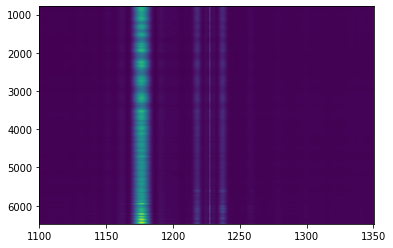

In [8]:
plt.imshow(sims.simulation_TOD_slice.T, aspect='auto', extent=extent)
plt.show()

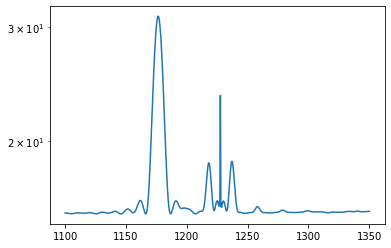

In [22]:
plt.plot(freq_range, np.mean(sims.simulation_TOD_slice, axis=1))

Estimating the noise:

$
\sigma^{2}(t, \nu) =\dfrac{T_{sys}^2(t,\nu)}{\Delta \nu \Delta t}
$

But also multiply with the number of antennae as well $\\\\$
$T_{sys}=15K$

Eq33 http://arxiv.org/abs/2011.13789


In [10]:
sim_tod = sims.simulation_TOD_slice.T
t_sys = 15 # K
del_nu = 0.2 # MHz
del_t = 2 # seconds
ant_no = 64

sigma = t_sys / np.sqrt(ant_no*del_nu*del_t)

In [11]:
# Adding the gaussian distribution to the sim data

gaus_tod = np.random.normal(sim_tod, sigma)

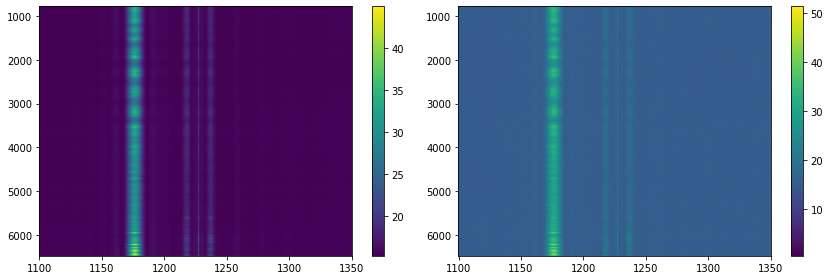

In [12]:
fig, (ax1,ax2) = plt.subplots(1,2, figsize=(12,4))
a1 = ax1.imshow(sim_tod, aspect='auto', extent=extent)
fig.colorbar(a1, ax=ax1)

a2 = ax2.imshow(gaus_tod, aspect='auto', extent=extent)
fig.colorbar(a2, ax=ax2)

plt.tight_layout()

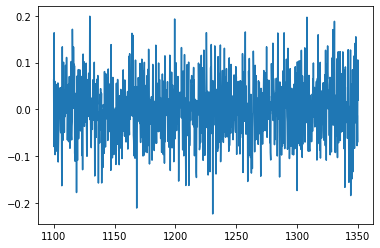

In [27]:
plt.plot(freq_range, np.mean(sim_tod, axis=0) - np.mean(gaus_tod, axis=0))


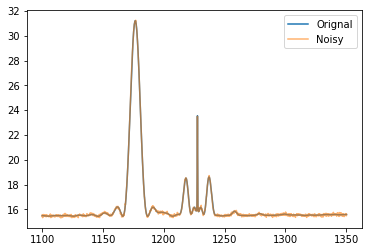

In [59]:
plt.plot(freq_range, np.mean(sim_tod, axis=0), label='Orignal')
plt.plot(freq_range, np.mean(gaus_tod, axis=0), alpha=0.6, label='Noisy')
plt.legend()


Running the validation for the chi2

In [40]:
%load_ext autoreload
%autoreload 2

%reload_ext autoreload

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [32]:
# dic = {'Alpha':np.random.random(71)}    # Feeding a dictionary of random entries between 0 and 1
dic = {'Alpha':np.ones(71)} 

In [49]:
def chisq_func2(a_param):
    """
    Chi2 function which will take in all the parameters for the satellites
    """

    sims.excecute(a_param, obs_time_start=nd_s0[1], obs_time_end=nd_s0[-2], obs_frequency_start=1100, obs_frequency_end=1350, 
            file_bias_choice=[1, 0,0,0,0,0,0], add_sub=[1, 1], band_lvl=[None, None])

    
    
    simulation = sims.simulation_TOD_slice.T
    data = gaus_tod
    
    chi_sq = np.sum(((simulation) - (data))**2 / (data)**2)
    print (chi_sq)
    print (a_param)
    print ('\n')
    return chi_sq

In [50]:
chisq_func2(dic['Alpha'])

134804.64872613567
[1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.
 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.
 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]




134804.64872613567

In [47]:
x = (0., 2)
# bnds = [x for i in range(len(dic['Alpha']))]
bnds = [x for i in range(len(dic['Alpha']))]

In [51]:
s_time = time.time()


signal_PL = opt.minimize(fun=chisq_func2, 
                         x0=dic['Alpha'], 
                         method='Powell',
                         bounds=bnds, 
                         tol=1e-3, 
                         options={'maxiter':20})

print (time.time() - s_time)

134804.64872613567
[1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.
 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.
 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]


134804.16076900778
[0.76393202 1.         1.         1.         1.         1.
 1.         1.         1.         1.         1.         1.
 1.         1.         1.         1.         1.         1.
 1.         1.         1.         1.         1.         1.
 1.         1.         1.         1.         1.         1.
 1.         1.         1.         1.         1.         1.
 1.         1.         1.         1.         1.         1.
 1.         1.         1.         1.         1.         1.
 1.         1.         1.         1.         1.         1.
 1.         1.         1.         1.         1.         1.
 1.         1.         1.         1.         1.         1.
 1.         1.         1.         1.         1.        ]


134805.13669908355
[1.23606798 1.  

In [52]:
3775.0738894939423 / 60 / 60


1.0486316359705394

In [ ]:
sing

In [64]:
sims.excecute(signal_PL.x, obs_time_start=nd_s0[1], obs_time_end=nd_s0[-2], obs_frequency_start=1100, obs_frequency_end=1350, 
        file_bias_choice=[1, 0,0,0,0,0,0], add_sub=[1, 1], band_lvl=[None, None])

In [65]:
sims.simulation_TOD_slice

masked_array(
  data=[[15.460186604846522, 15.4617061443652, 15.463396650417033, ...,
         15.617550976020999, 15.614529431929979, 15.617839689425654],
        [15.459925353272675, 15.461441575116737, 15.463123003788718, ...,
         15.616841661820924, 15.613815086839155, 15.617122273732837],
        [15.459382003367075, 15.460894345854685, 15.462562930072723, ...,
         15.615756373179797, 15.612728138663481, 15.616035092799597],
        ...,
        [15.585640467888553, 15.586423578417913, 15.58703244451819, ...,
         15.631459283240593, 15.62965364576294, 15.631197631752995],
        [15.5875967187719, 15.58838183556814, 15.588989655319105, ...,
         15.633211525036279, 15.63145260295638, 15.63303605417936],
        [15.589002956395905, 15.589789159042118, 15.590396243422854, ...,
         15.63447125198851, 15.632741049625048, 15.634348179988107]],
  mask=[[False, False, False, ..., False, False, False],
        [False, False, False, ..., False, False, False],
    